In [53]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib as mpl
import matplotlib.pyplot as plt
import gseapy as gp

In [86]:
fm.fontManager.addfont('/nfs/team361/am74/Cytomeister/Evaluation_datasets/LPS/Private_emily/helvetica.ttf')

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.grid'] = False
sc.set_figure_params(dpi_save=600,fontsize=12)

In [55]:
adata = sc.read('/nfs/team361/am74/Cytomeister/configs/results/results/20260113-16:40_minference_adata_gENSG00000125538_ssrc_tmask.h5ad')

In [56]:
pred = adata.copy()
pred.X = pred.layers['pred_counts'].copy()

In [57]:
pred.obs['status'] = 'unperturbed'
adata.obs['status'] = 'perturbed'

In [58]:
adata.obs['status_time'] = 'perturbed_' + adata.obs['time_after_LPS'].astype(str)
pred.obs['status_time'] = 'unperturbed_' + pred.obs['time_after_LPS'].astype(str)

In [59]:
adata = adata.concatenate(pred)

/tmp/ipykernel_4071960/3760186430.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata.concatenate(pred)


In [60]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [61]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata.obs['cell_type_harmonized'] = adata.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata.obs['cell_type_harmonized'].cat.categories}
)

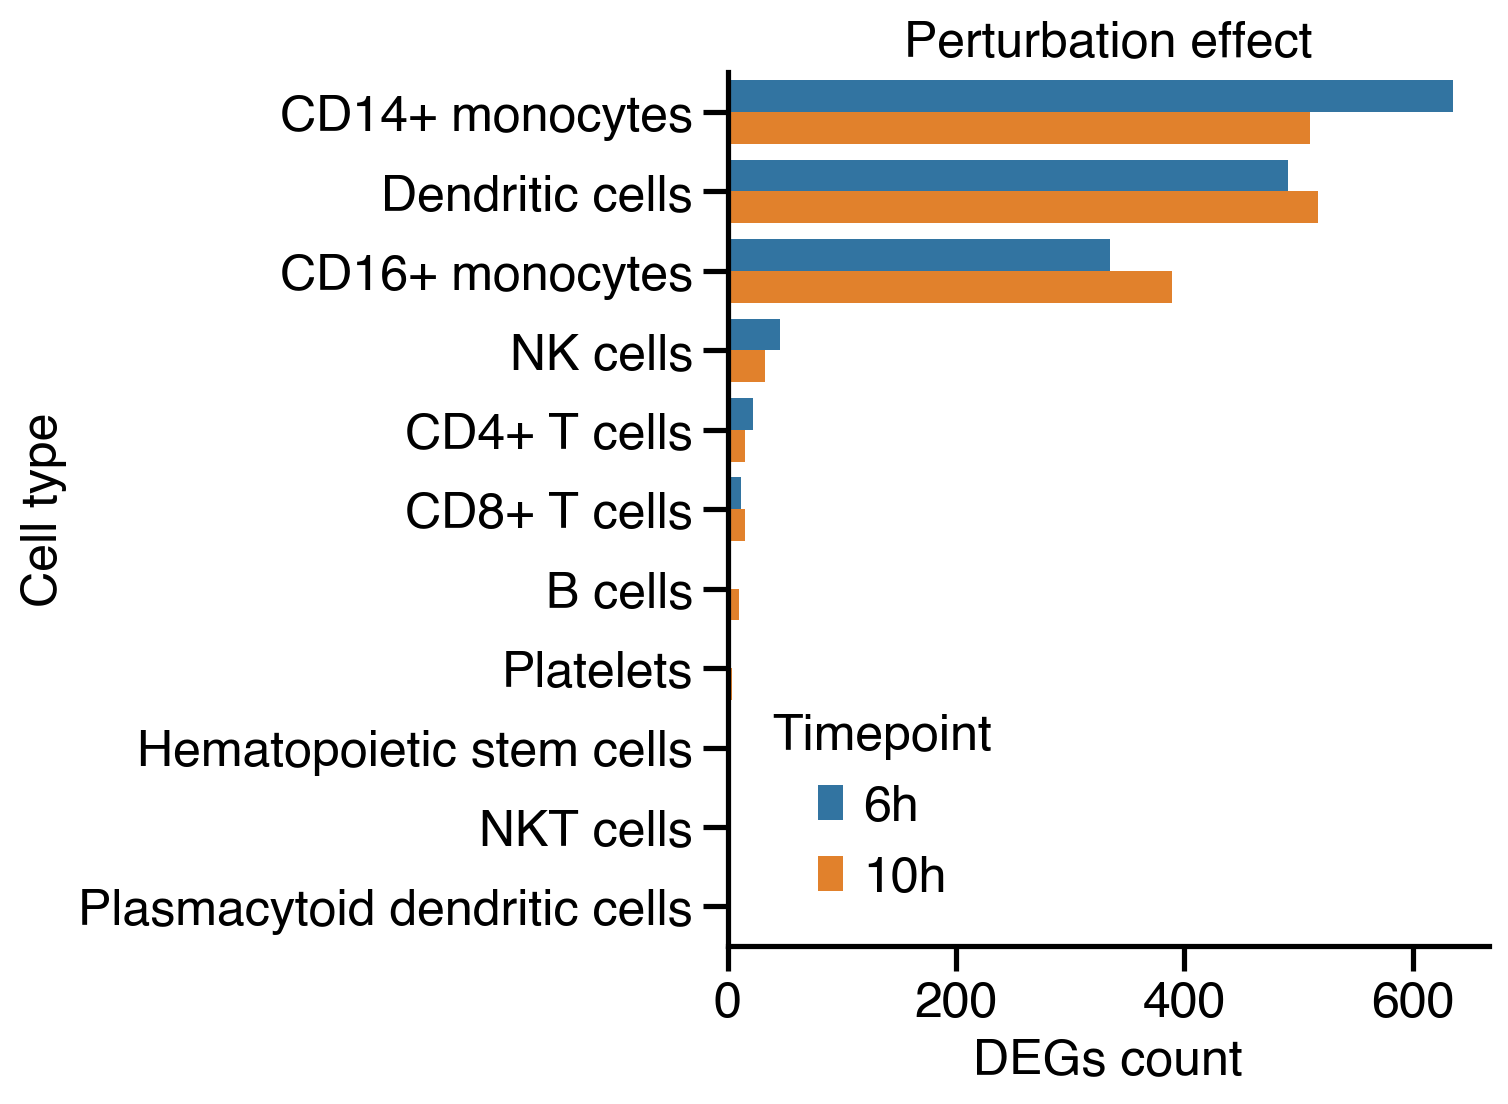

In [62]:
mpl.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

cell_types = adata.obs['cell_type_harmonized'].unique()
timepoints = ['6h_LPS', '10h_LPS']
results = []

for tp in timepoints:
    unperturbed = f'unperturbed_{tp}'
    perturbed   = f'perturbed_{tp}'

    for ct in cell_types:
        mask_pert = (adata.obs['status_time'] == perturbed) & (adata.obs['cell_type_harmonized'] == ct)
        mask_unpt = (adata.obs['status_time'] == unperturbed) & (adata.obs['cell_type_harmonized'] == ct)

        # Require at least 2 cells per group
        if mask_pert.sum() < 2 or mask_unpt.sum() < 2:
            print(f"Skipping: {ct} at {tp} (pert={mask_pert.sum()}, unpert={mask_unpt.sum()})")
            continue

        sub_adata = adata[mask_pert | mask_unpt].copy()
        sub_adata.obs['group'] = 'unperturbed'
        sub_adata.obs.loc[sub_adata.obs['status_time'] == perturbed, 'group'] = 'perturbed'
        sub_adata.obs['group'] = sub_adata.obs['group'].astype('category')

        sc.tl.rank_genes_groups(sub_adata, groupby='group', reference='unperturbed', method='wilcoxon')

        degs = sc.get.rank_genes_groups_df(sub_adata, group='perturbed') 
        deg_count = (degs['pvals_adj'] < 0.05).sum()
        results.append({'cell_type': ct, 'timepoint': tp, 'deg_count': deg_count})


df = pd.DataFrame(results)
df_sorted = df.sort_values(by='deg_count', ascending=False)
df_sorted['timepoint'] = df_sorted['timepoint'].replace({
    '6h_LPS': '6h',
    '10h_LPS': '10h'
})
sns.set_context("talk", font_scale=1.2)  
plt.figure(figsize=(8, 6))
sns.barplot(data=df_sorted, y='cell_type', x='deg_count', hue='timepoint')
plt.ylabel('Cell type', fontsize=18)
plt.xlabel('DEGs count', fontsize=18)
plt.title('Perturbation effect', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(title='Timepoint', fontsize=18, title_fontsize=18)
plt.tight_layout()
plt.grid(False)
plt.savefig("./perturbation_effect.svg", dpi=600, bbox_inches="tight")
plt.show()

In [63]:
adata = adata[adata.obs['cell_type_harmonized'].isin(['CD14+ monocytes','Dendritic cells',
                                                     'CD16+ monocytes'])].copy()

In [64]:
adata_full = sc.read('/nfs/team361/am74/Cytomeister/Evaluation_datasets/LPS/full_lps.h5ad')

In [65]:
sc.pp.normalize_total(adata_full)
sc.pp.log1p(adata_full)

In [66]:
adata_full.var_names = adata_full.var['gene_ids-0']

Running DE for timepoint: 6h_LPS


/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


Running DE for timepoint: 10h_LPS


/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


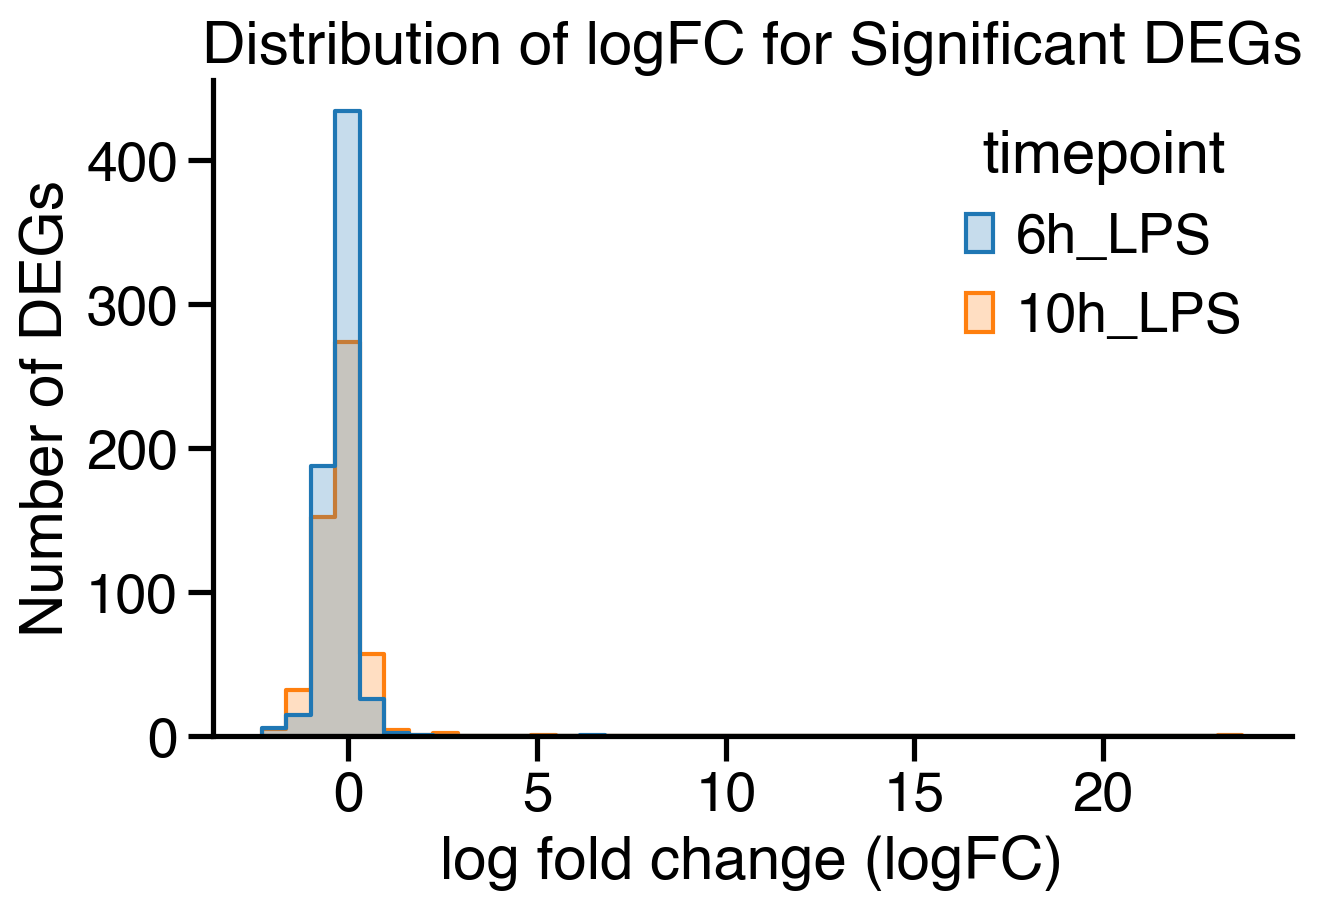

In [67]:
adata.obs[['status','time']] = adata.obs['status_time'].str.split('_', n=1, expand=True)

degs = {}


for tp in adata.obs['time'].unique():
    print(f"Running DE for timepoint: {tp}")

    ad = adata[adata.obs['time'] == tp]

    sc.tl.rank_genes_groups(
        ad,
        groupby="status",
        groups=["perturbed"],
        reference="unperturbed",
        method="wilcoxon"
    )
    
    df = sc.get.rank_genes_groups_df(ad, group="perturbed")

    sig = df[df["pvals_adj"] < 0.05]

    degs[tp] = sig

logfc_df = []

for tp, df in degs.items():
    tmp = pd.DataFrame({
        "logFC": df["logfoldchanges"],
        "timepoint": tp
    })
    logfc_df.append(tmp)

logfc_df = pd.concat(logfc_df)


plt.figure(figsize=(7,5))

sns.histplot(
    data=logfc_df,
    x="logFC",
    hue="timepoint",
    bins=40,
    element="step",
    kde=False   
)

plt.title("Distribution of logFC for Significant DEGs")
plt.xlabel("log fold change (logFC)")
plt.ylabel("Number of DEGs")
plt.tight_layout()
plt.grid(False)
plt.savefig('./DEG_distribution.svg')
plt.show()

In [68]:
adata_full.var_names = adata_full.var['ensembl_id-0']

/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['ENSG00000177757', 'ENSG00000225880', 'ENSG00000230368', 'ENSG00000188976', 'ENSG00000187961']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


In [69]:
mapping = adata_full.var['gene_ids-0'].to_dict()
adata.var_names = adata.var_names.map(mapping)
adata = adata[:, adata.var_names.notnull()].copy()

In [70]:
adata_full.var_names = adata_full.var['gene_ids-0']

In [71]:
adatafull_myeloids = adata_full[adata_full.obs['cell_type_harmonized'].isin(['CD14+ monocytes','Dendritic cells',
                                                     'CD16+ monocytes'])].copy()

### Parsebio

In [72]:
IL1B = sc.read('/nfs/team361/am74/Cytomeister/notebooks/IL1B_KO_analysis/IL1B_myeloid.h5ad')

In [73]:
IL1B.X.max()

np.float32(5.860427)

In [74]:
adata_IL1B = IL1B.copy()
groupby_key = "cytokine"
sc.tl.rank_genes_groups(
    adata_IL1B,
    groupby=groupby_key,
    method="wilcoxon",
    reference="PBS"   
)

In [75]:
degs = sc.get.rank_genes_groups_df(adata_IL1B, group='IL-1-beta')
alpha = 0.05
logfc_cutoff = 0.2  
sig_degs = degs[(degs['pvals_adj'] < alpha) & (abs(degs['logfoldchanges']) > logfc_cutoff)]
up_degs = sig_degs[sig_degs['logfoldchanges'] > 0.2]
down_degs = sig_degs[sig_degs['logfoldchanges'] < 0.2]
print("Upregulated genes:", up_degs.head())
print("Downregulated genes:", down_degs.head())

Upregulated genes:       names      scores  logfoldchanges  pvals  pvals_adj
0      CD68  133.634979        1.376529    0.0        0.0
1  SERPING1  107.055588        1.428589    0.0        0.0
2      GBP1  101.584961        1.158601    0.0        0.0
3    CSF2RB  101.195122        1.360826    0.0        0.0
4      IDO1   97.084709        1.509949    0.0        0.0
Downregulated genes:        names    scores  logfoldchanges     pvals  pvals_adj
1422    RGCC -2.284171       -0.809586  0.022362   0.048974
1423   SMAD1 -2.287478       -0.214117  0.022168   0.048604
1424  PRUNE1 -2.294461       -0.379817  0.021764   0.047876
1427  TREML1 -2.326238       -1.436381  0.020006   0.044302
1429   SAP30 -2.346582       -0.715973  0.018947   0.042143


In [76]:
adata_6h = adata[adata.obs['time_after_LPS']=='6h_LPS'].copy()
adata_10h = adata[adata.obs['time_after_LPS']=='10h_LPS'].copy()

/tmp/ipykernel_4071960/3814101785.py:78: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  plt.tight_layout()
/tmp/ipykernel_4071960/3814101785.py:78: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_4071960/3814101785.py:79: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  plt.savefig('./GT_pathways.svg')
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


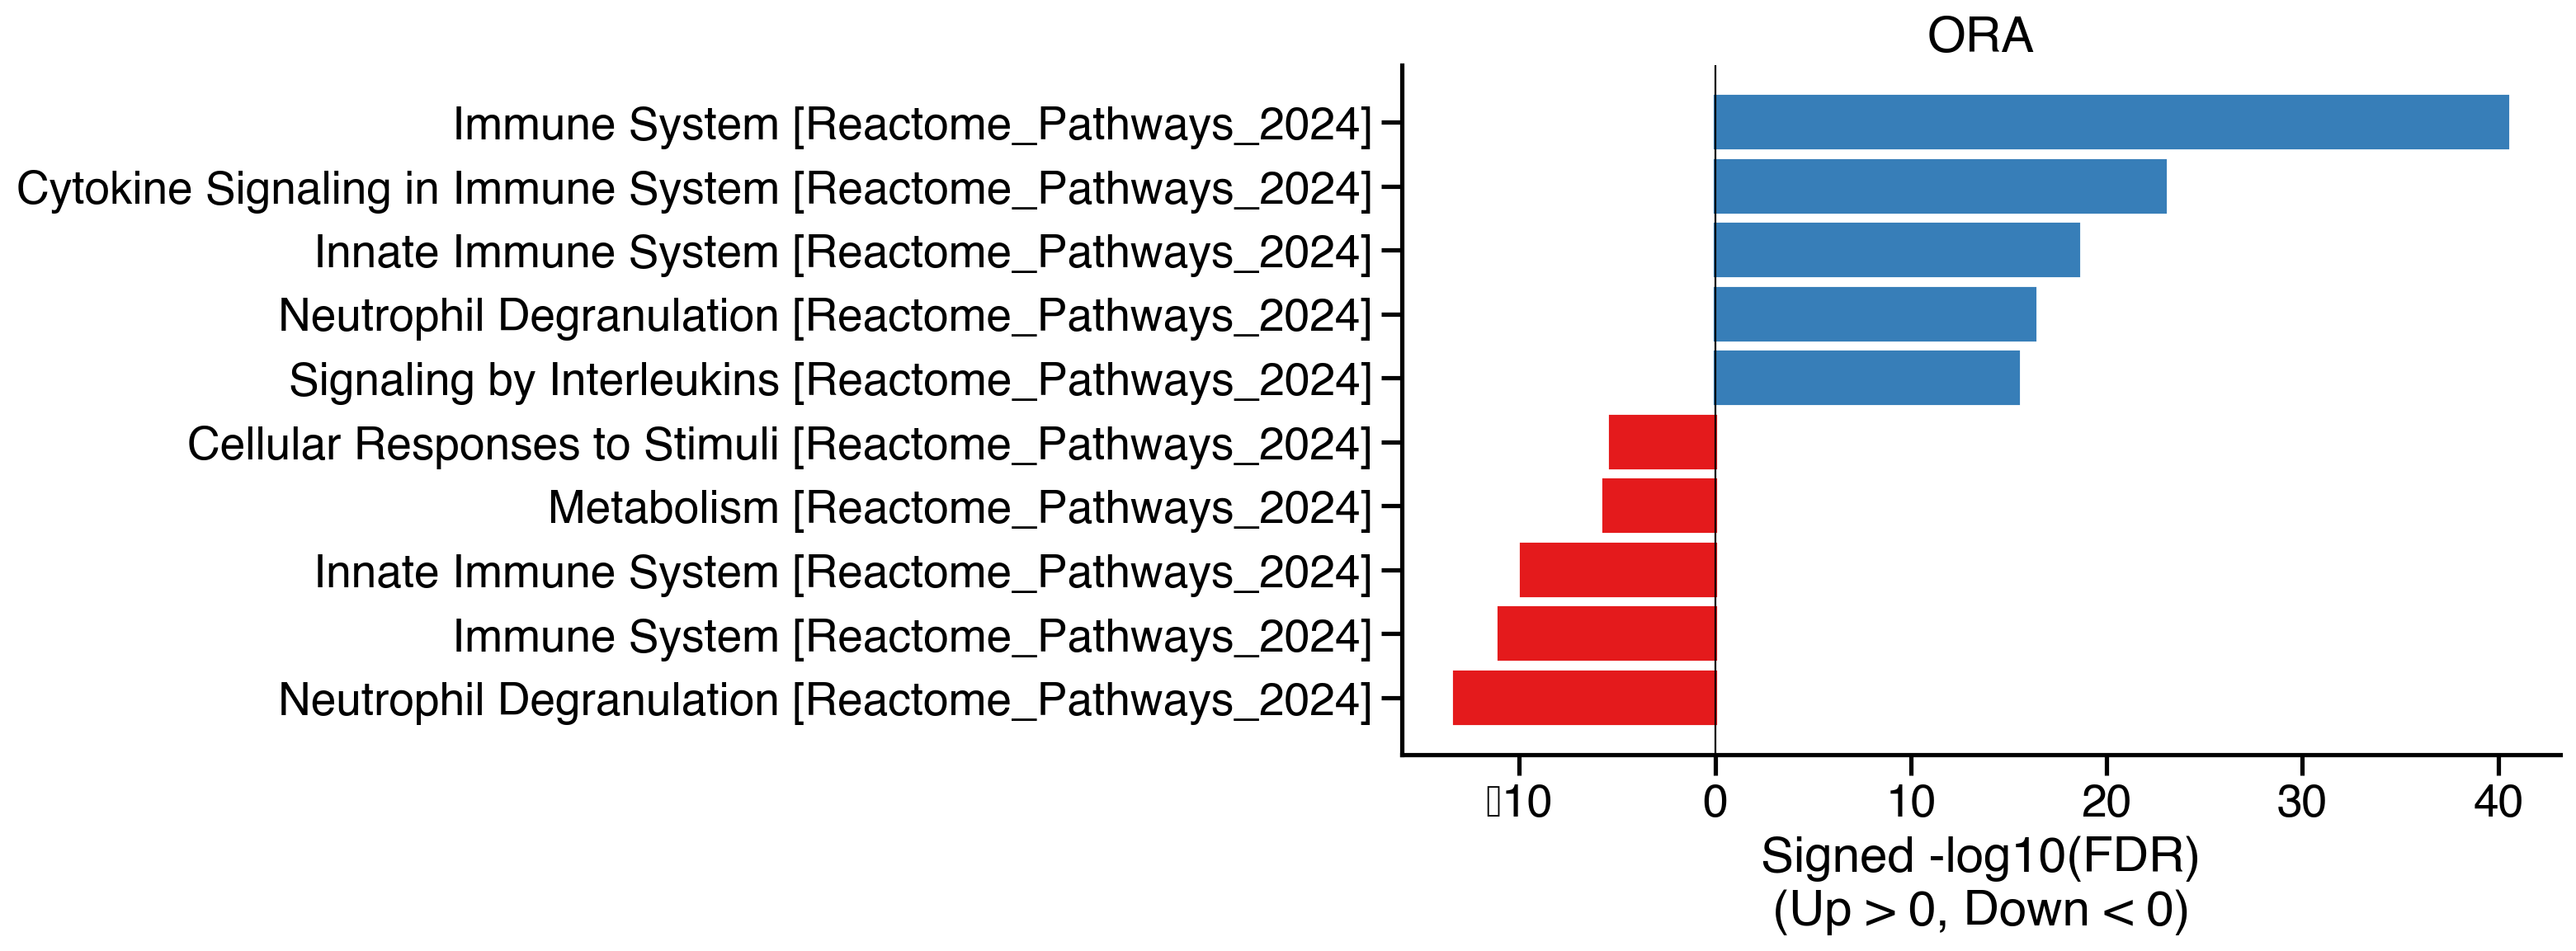

In [77]:
up_genes = (up_degs['names'].dropna().astype(str).str.strip().unique().tolist())
down_genes = (down_degs['names'].dropna().astype(str).str.strip().unique().tolist())
up_enr = gp.enrichr(
    gene_list=up_genes,
    gene_sets='Reactome_Pathways_2024',
    organism='Human',         
    cutoff=1.0,               
    outdir=None,              
    verbose=False
)
down_enr = gp.enrichr(
    gene_list=down_genes,
    gene_sets='Reactome_Pathways_2024',
    organism='Human',
    cutoff=1.0,
    outdir=None,
    verbose=False
)
def prep_enrichr_df(enr_results: gp.enrichr) -> pd.DataFrame:
    if enr_results is None or enr_results.results is None:
        return pd.DataFrame(columns=['Term', 'Adjusted P-value', 'Gene_set'])
    df = enr_results.results.copy()

    keep = ['Term', 'Adjusted P-value', 'Combined Score', 'Odds Ratio', 'Overlap', 'Genes', 'Gene_set']
    for k in keep:
        if k not in df.columns:
            df[k] = np.nan

    # Convert to numeric
    df['Adjusted P-value'] = pd.to_numeric(df['Adjusted P-value'], errors='coerce')
    df['neglog10FDR'] = -np.log10(df['Adjusted P-value'].replace(0, np.nextafter(0, 1)))

    # Parse Overlap ("k/n") and keep only if k >= 10
    df[['Overlap_hits', 'Overlap_total']] = df['Overlap'].str.split('/', expand=True).astype(float)
    df = df[df['Overlap_hits'] >= 5]

    return df[keep + ['neglog10FDR', 'Overlap_hits', 'Overlap_total']]


up_df = prep_enrichr_df(up_enr)
down_df = prep_enrichr_df(down_enr)

alpha = 0.05
top_k = 5  

up_sig = up_df[up_df['Adjusted P-value'] < alpha].copy()
down_sig = down_df[down_df['Adjusted P-value'] < alpha].copy()

up_sig = up_sig.sort_values('neglog10FDR', ascending=False).head(top_k)
down_sig = down_sig.sort_values('neglog10FDR', ascending=False).head(top_k)

up_sig['direction'] = 'Up'
down_sig['direction'] = 'Down'
up_sig['signed_score'] = up_sig['neglog10FDR']
down_sig['signed_score'] = -down_sig['neglog10FDR']

plot_df = pd.concat([up_sig, down_sig], axis=0, ignore_index=True)

plot_df['Label'] = plot_df['Term'] + ' [' + plot_df['Gene_set'].str.replace('_2021|_2022', '', regex=True) + ']'

plot_df = plot_df.sort_values('signed_score')

plt.figure(figsize=(9, 0.45 * len(plot_df) + 1))
y_pos = np.arange(len(plot_df))
bars = plt.barh(y_pos, plot_df['signed_score'])

for i, d in enumerate(plot_df['direction']):
    if d == 'Up':
        bars[i].set_color('#377eb8')  
    else:
        bars[i].set_color('#e41a1c')  

plt.yticks(y_pos, plot_df['Label'])
plt.axvline(0, color='k', linewidth=0.8)
plt.xlabel('Signed -log10(FDR)\n(Up > 0, Down < 0)')
plt.title('ORA')
plt.grid(False)
plt.tight_layout()
plt.savefig('./GT_pathways.svg')
plt.show()

In [78]:
def filter_genes_by_expression(adata, min_frac=0.2):
    """Keep only genes expressed in at least min_frac fraction of cells."""
    frac = (adata.X > 0).mean(axis=0)
    frac = np.array(frac).ravel()

    keep_genes = adata.var_names[frac >= min_frac]
    return adata[:, keep_genes].copy()


adata_6h = adata[adata.obs['status_time'].isin(
    ['perturbed_6h_LPS', 'unperturbed_6h_LPS']
)].copy()

adata_6h = filter_genes_by_expression(adata_6h, min_frac=0.0)


sc.tl.rank_genes_groups(adata_6h, groupby='status_time', method='wilcoxon',
                        groups=['perturbed_6h_LPS'], reference='unperturbed_6h_LPS')
degs_6h = sc.get.rank_genes_groups_df(adata_6h, group='perturbed_6h_LPS')


adata_10h = adata[adata.obs['status_time'].isin(
    ['perturbed_10h_LPS', 'unperturbed_10h_LPS']
)].copy()

adata_10h = filter_genes_by_expression(adata_10h, min_frac=0.0)

sc.tl.rank_genes_groups(adata_10h, groupby='status_time', method='wilcoxon',
                        groups=['perturbed_10h_LPS'], reference='unperturbed_10h_LPS')
degs_10h = sc.get.rank_genes_groups_df(adata_10h, group='perturbed_10h_LPS')


In [79]:
adj_pval_cutoff = 0.05
logfc_cutoff = 0.2   

degs_6h_filtered = degs_6h[
    (degs_6h["pvals_adj"] < adj_pval_cutoff) &
    (degs_6h["logfoldchanges"].abs() > logfc_cutoff)
]

degs_10h_filtered = degs_10h[
    (degs_10h["pvals_adj"] < adj_pval_cutoff) &
    (degs_10h["logfoldchanges"].abs() > logfc_cutoff)
]

combined_degs = pd.concat([up_degs, down_degs], ignore_index=True)

intersection_6h = set(degs_6h_filtered["names"]) & set(combined_degs["names"])
intersection_10h = set(degs_10h_filtered["names"]) & set(combined_degs["names"])

intersection_6h_df = degs_6h_filtered[degs_6h_filtered["names"].isin(intersection_6h)]
intersection_10h_df = degs_10h_filtered[degs_10h_filtered["names"].isin(intersection_10h)]

print(f"6h intersection genes ({len(intersection_6h)})")
print(f"10h intersection genes ({len(intersection_10h)})")


6h intersection genes (221)
10h intersection genes (192)


In [80]:
down_6h = (
    degs_6h_filtered
    .loc[degs_6h_filtered["logfoldchanges"] < 0, "names"]
    .dropna()
    .unique()
    .tolist()
)

down_10h = (
    degs_10h_filtered
    .loc[degs_10h_filtered["logfoldchanges"] < 0, "names"]
    .dropna()
    .unique()
    .tolist()
)
import gseapy as gp

ora_6h = gp.enrichr(
    gene_list=down_6h,
    gene_sets="Reactome_Pathways_2024",
    organism="Human",
    outdir=None
)

ora_10h = gp.enrichr(
    gene_list=down_10h,
    gene_sets="Reactome_Pathways_2024",
    organism="Human",
    outdir=None
)
res_6h = ora_6h.results
res_10h = ora_10h.results
top_6h = res_6h.sort_values("Adjusted P-value").head(10)
top_10h = res_10h.sort_values("Adjusted P-value").head(10)

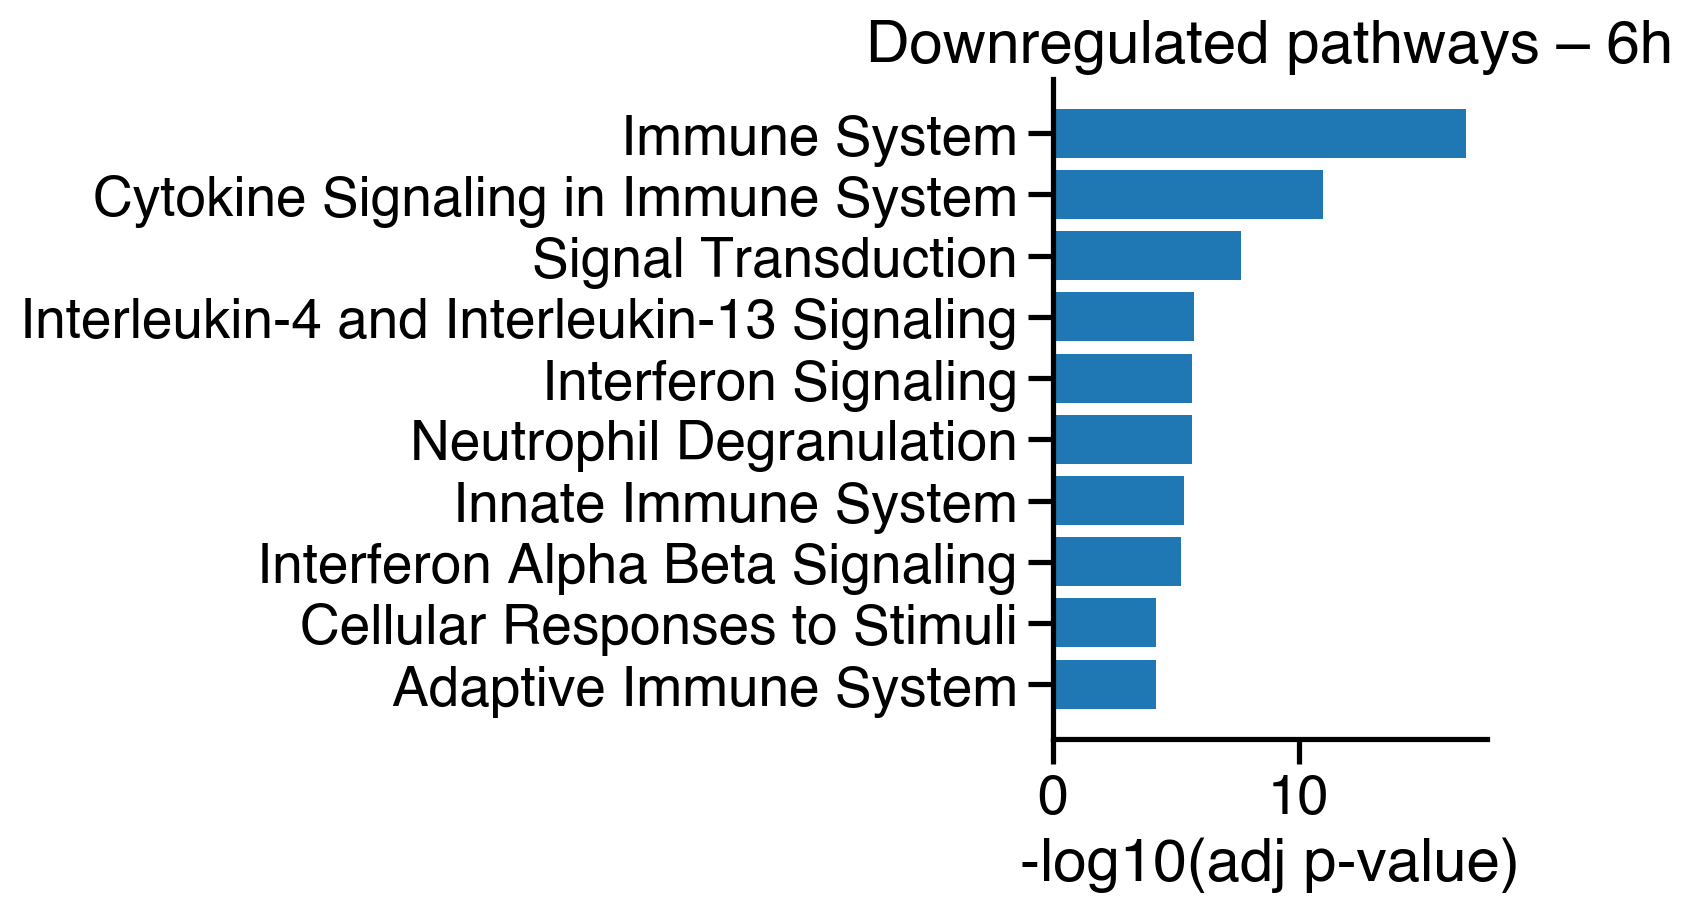

In [29]:
plt.figure(figsize=(8, 5))

plt.barh(
    top_6h["Term"],
    -np.log10(top_6h["Adjusted P-value"]),
    color="#1f77b4"
)

plt.xlabel("-log10(adj p-value)")
plt.title("Downregulated pathways – 6h")
plt.gca().invert_yaxis()
plt.grid(False)

plt.tight_layout()
plt.savefig('down_pathways_6h.svg',dpi=600)
plt.show()


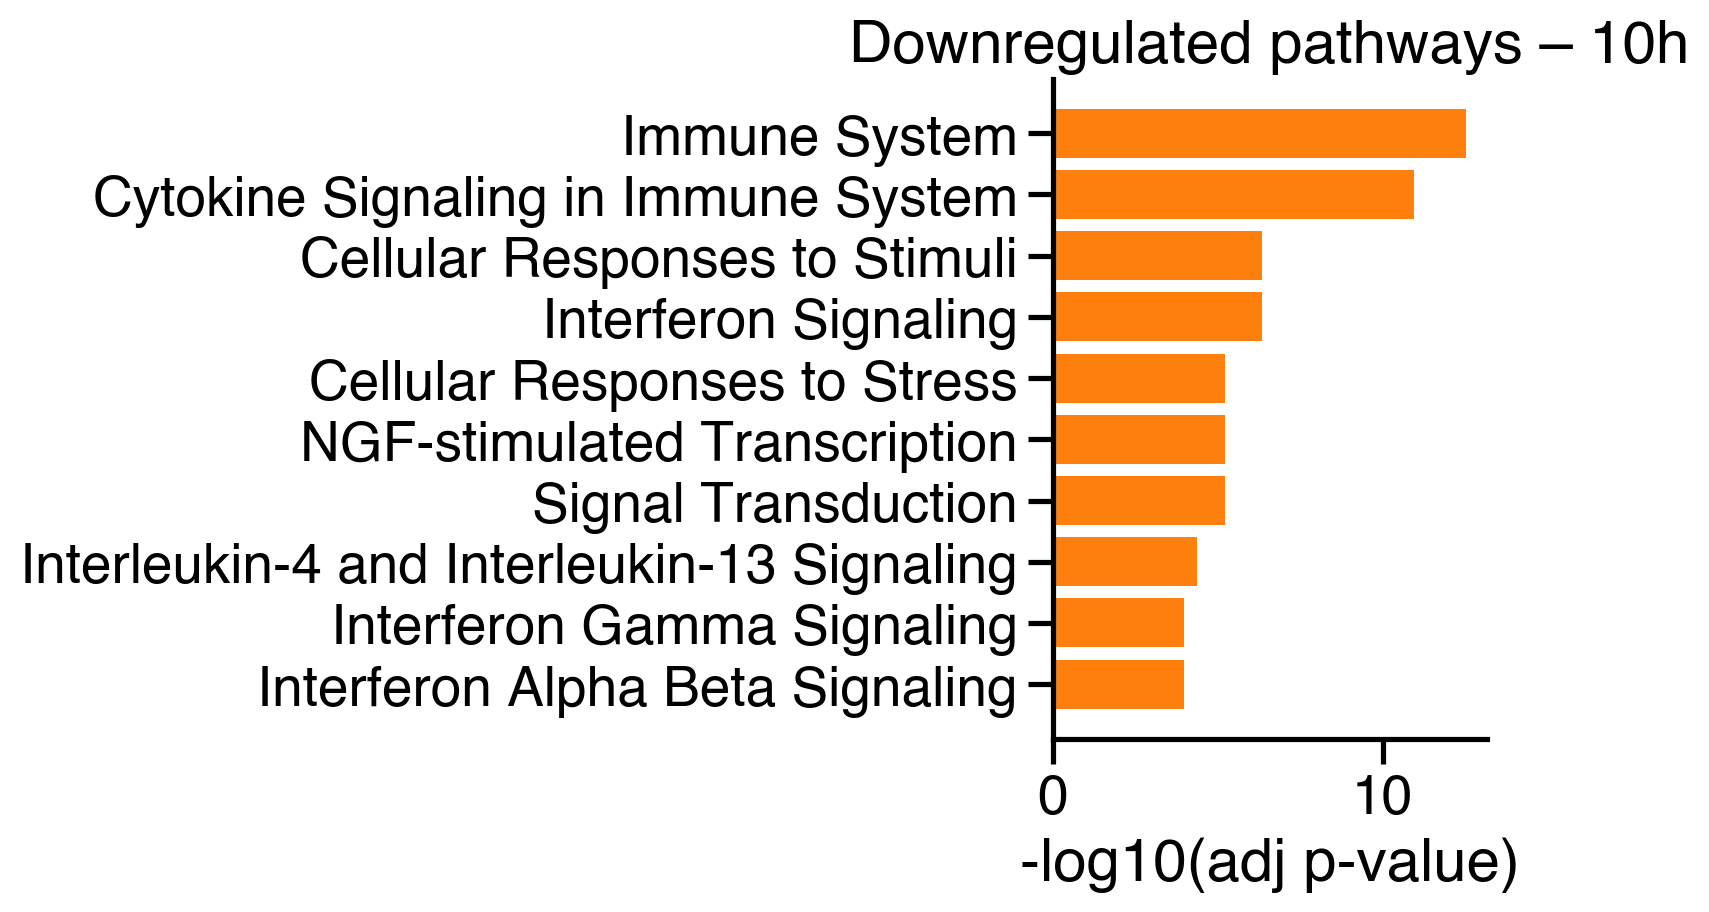

In [30]:
plt.figure(figsize=(8, 5))

plt.barh(
    top_10h["Term"],
    -np.log10(top_10h["Adjusted P-value"]),
    color="#ff7f0e"
)

plt.xlabel("-log10(adj p-value)")
plt.title("Downregulated pathways – 10h")
plt.gca().invert_yaxis()
plt.grid(False)

plt.tight_layout()
plt.savefig('down_pathways_10.svg',dpi=600)
plt.show()


In [31]:
def get_pathway_genes(df):
    gene_sets = {}
    for _, row in df.iterrows():
        term = row['Term']
        genes = [g.strip() for g in row['Genes'].split(';') if g.strip()]
        gene_sets[term] = genes
    return gene_sets

up_pathway_genes = get_pathway_genes(up_sig)
down_pathway_genes = get_pathway_genes(down_sig)


In [32]:
logfc_6h = dict(zip(degs_6h['names'], degs_6h['logfoldchanges']))
logfc_10h = dict(zip(degs_10h['names'], degs_10h['logfoldchanges']))

In [33]:
def pathway_signed_score(pathway_genes, logfc_dict):
    scores = {}
    for term, genes in pathway_genes.items():
        val = 0
        for g in genes:
            if g in logfc_dict:
                val += 1 if logfc_dict[g] > 0 else -1
        scores[term] = val
    return scores


In [34]:
def get_pathway_top_genes(df, top_n=10, min_genes=5):
    terms = df.sort_values('Adjusted P-value').copy()
    gene_sets = {}
    for _, row in terms.iterrows():
        genes = row['Genes'].split(';')
        if len(genes) >= min_genes:
            term = row['Term']
            gene_sets[term] = genes
            if len(gene_sets) == top_n:
                break
    return gene_sets

il1b_pathway_genes = get_pathway_top_genes(up_sig, top_n=5, min_genes=5)

In [35]:
score_6h  = pathway_signed_score(il1b_pathway_genes, logfc_6h)
score_10h = pathway_signed_score(il1b_pathway_genes, logfc_10h)

# IL1B direction = +1 for all genes
score_il1b = {term: len(genes) for term, genes in il1b_pathway_genes.items()}


In [36]:
score_il1b

{'Immune System': 115,
 'Cytokine Signaling in Immune System': 56,
 'Innate Immune System': 61,
 'Neutrophil Degranulation': 38,
 'Signaling by Interleukins': 36}

In [37]:
score_10h

{'Immune System': -15,
 'Cytokine Signaling in Immune System': -12,
 'Innate Immune System': 5,
 'Neutrophil Degranulation': 4,
 'Signaling by Interleukins': -10}

In [38]:
df_plot = pd.DataFrame([
    {'Term': t, 'Signed': v, 'Timepoint': 'IL-1β'} for t, v in score_il1b.items()
] + [
    {'Term': t, 'Signed': v, 'Timepoint': '6h'} for t, v in score_6h.items()
] + [
    {'Term': t, 'Signed': v, 'Timepoint': '10h'} for t, v in score_10h.items()
])

# Normalize to [-1, 1]
max_val = df_plot['Signed'].abs().max()
df_plot['Score_signed'] = df_plot['Signed'] / max_val

# Order by IL1B expectation
ordered_terms = (
    df_plot[df_plot["Timepoint"]=="IL-1β"]
    .sort_values("Score_signed")["Term"]
    .tolist()
)

pivot_df = df_plot.pivot(index="Term", columns="Timepoint", values="Score_signed").reindex(ordered_terms)
for col in ["6h","10h","IL-1β"]:
    if col not in pivot_df.columns:
        pivot_df[col] = 0.0


/tmp/ipykernel_4071960/4220625261.py:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  plt.tight_layout()
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


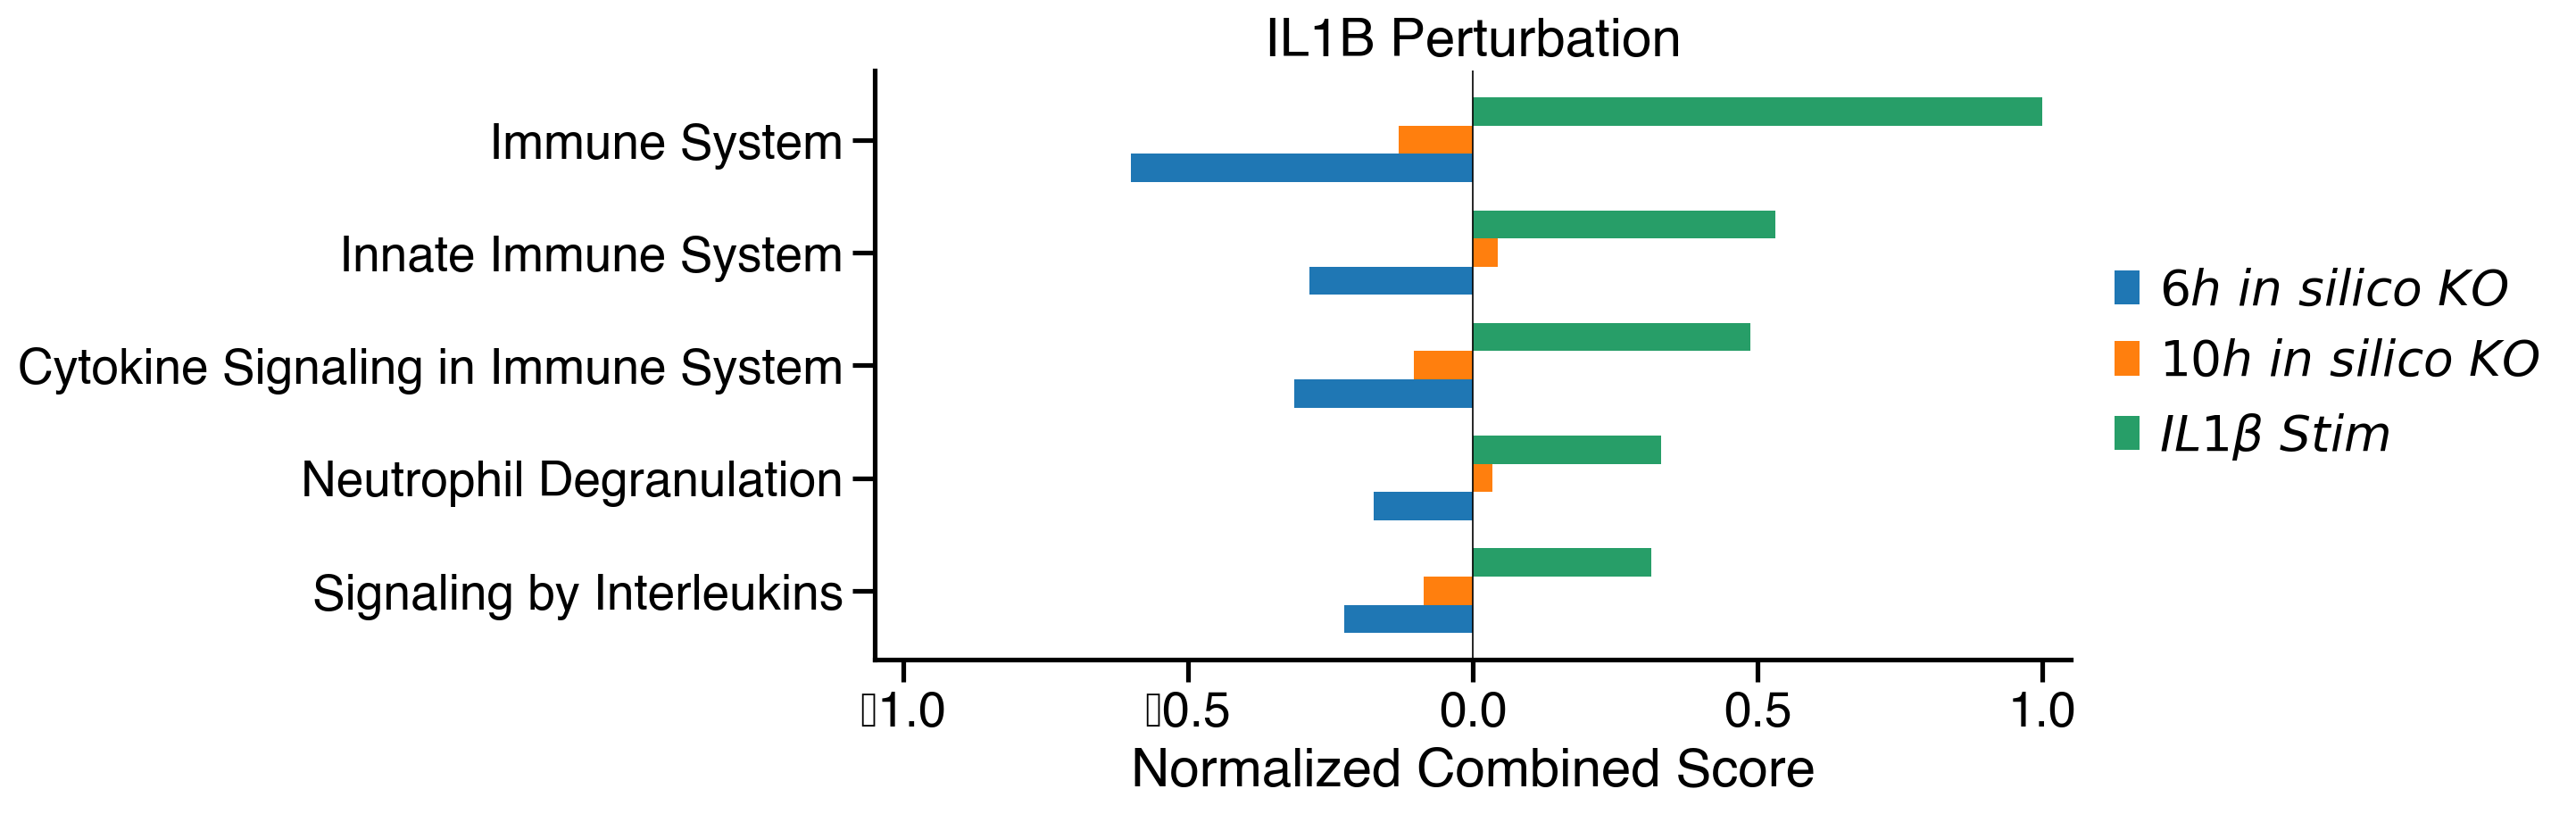

In [39]:
fig, ax = plt.subplots(figsize=(15, 5))
y = np.arange(len(pivot_df))
bar_h = 0.25

ax.barh(y - bar_h, pivot_df["6h"],     height=bar_h, label=r"$\it{6h\ in\ silico\ KO}$")
ax.barh(y,         pivot_df["10h"],    height=bar_h, label=r"$\it{10h\ in\ silico\ KO}$")
ax.barh(y + bar_h, pivot_df["IL-1β"],  height=bar_h, label=r"$\it{IL1\beta\ Stim}$")


ax.axvline(0, color="black", linewidth=0.6)
ax.set_yticks(y)
ax.set_yticklabels(pivot_df.index)
ax.set_xlim(-1.05, 1.05)
ax.set_xticks(np.linspace(-1, 1, 5))
ax.set_xlabel("Normalized Combined Score")
ax.set_title("IL1B Perturbation")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
plt.tight_layout()
plt.grid(False)
# Save to file
# plt.savefig('./pathways_direction_scores.svg', dpi=600, bbox_inches='tight')
plt.show()


/tmp/ipykernel_4071960/2232852208.py:46: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  plt.tight_layout()
/tmp/ipykernel_4071960/2232852208.py:49: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  plt.savefig('./pathways_direction_scores.svg', dpi=600, bbox_inches='tight')
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


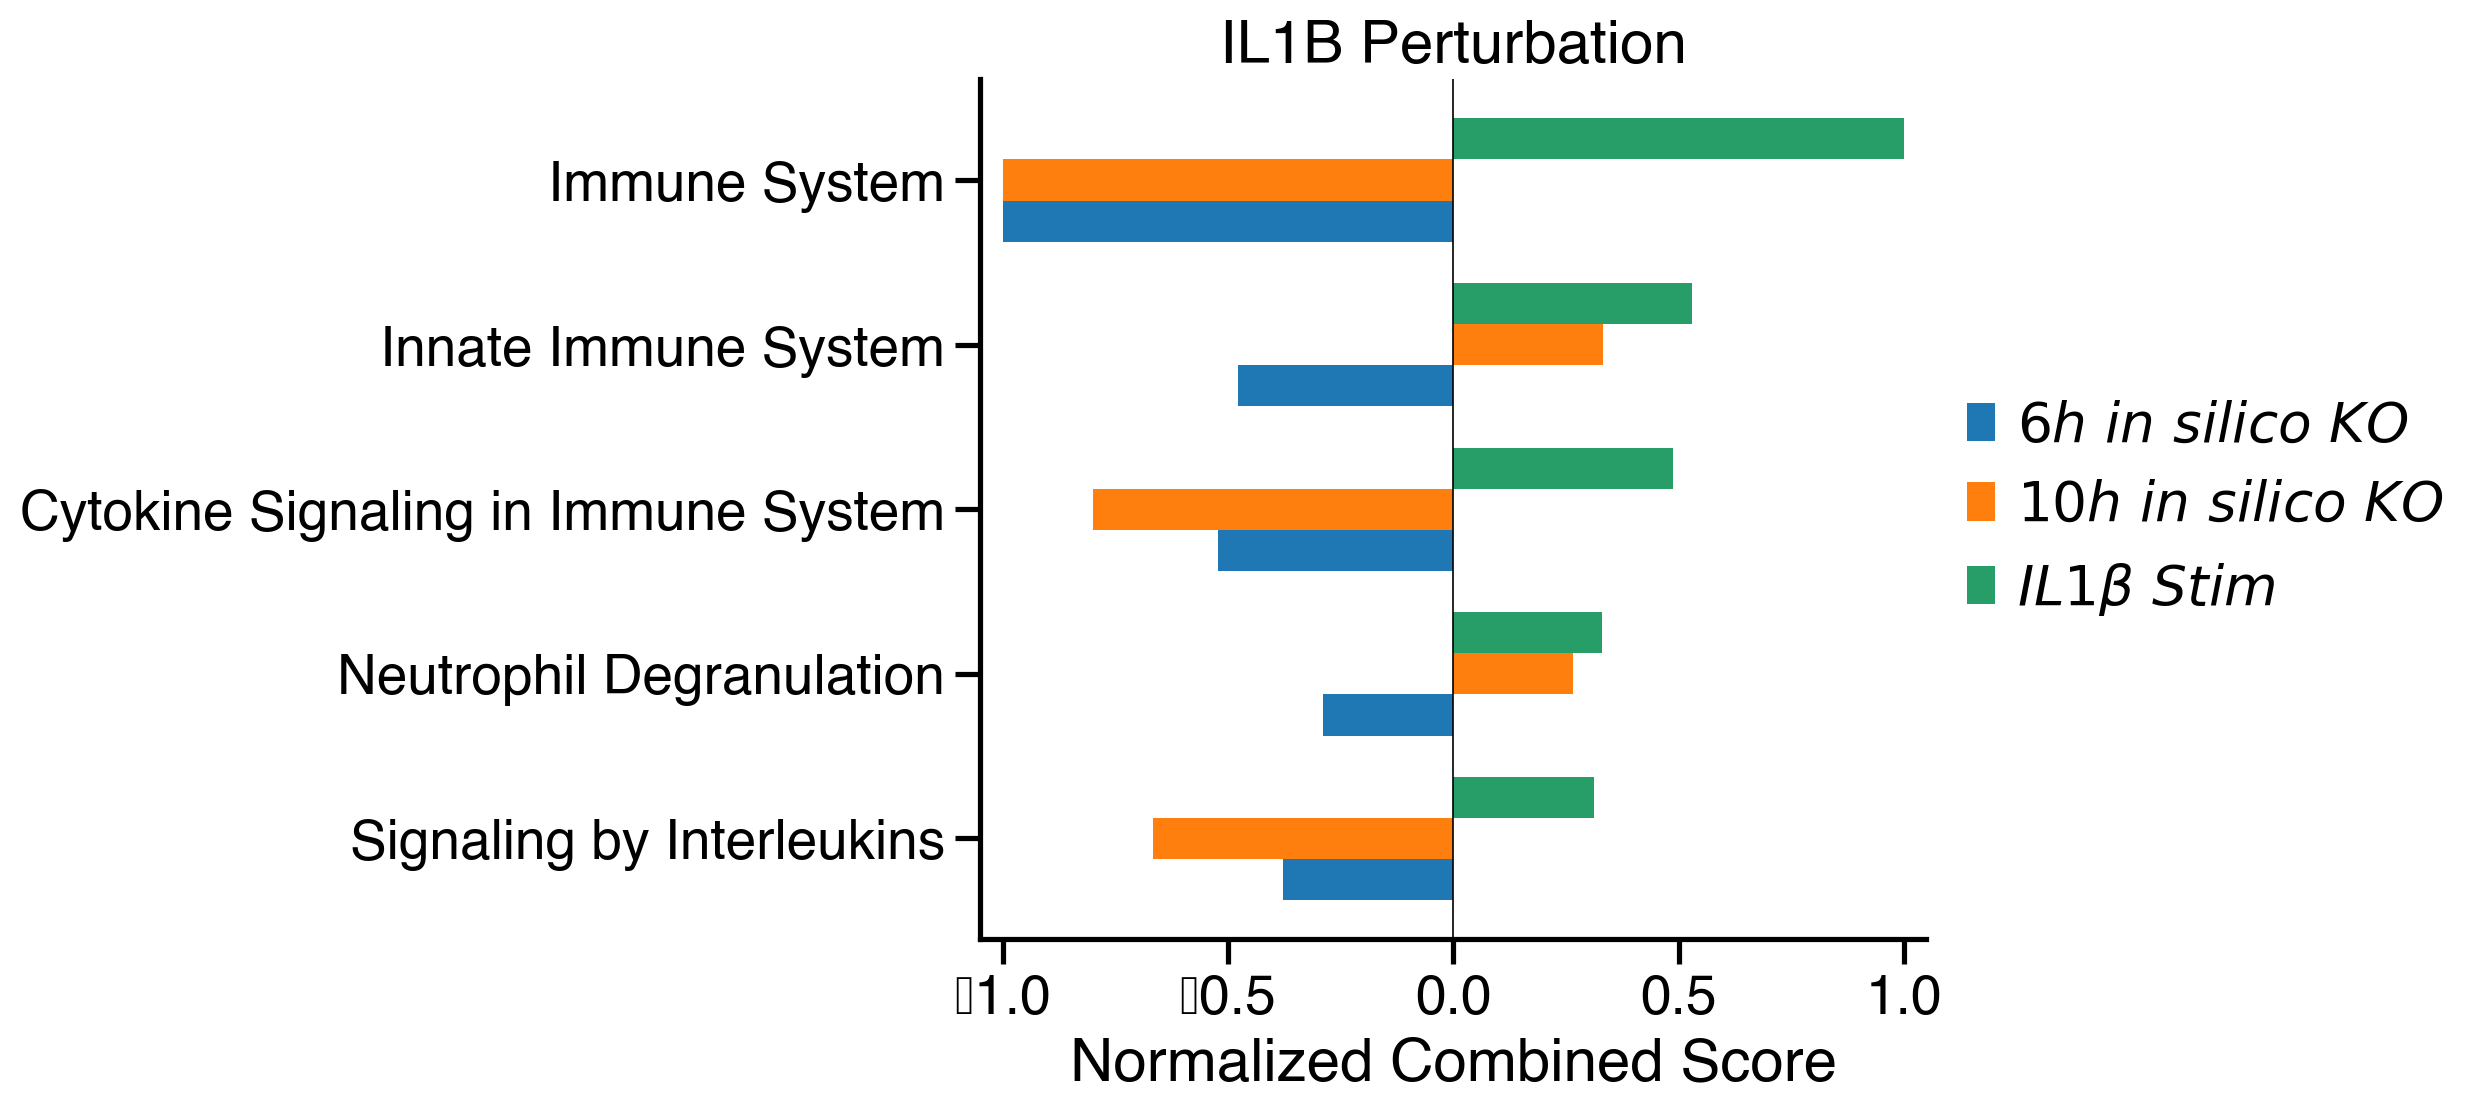

In [40]:
df_plot = pd.DataFrame([
    {'Term': t, 'Signed': v, 'Timepoint': 'IL-1β'} for t, v in score_il1b.items()
] + [
    {'Term': t, 'Signed': v, 'Timepoint': '6h'} for t, v in score_6h.items()
] + [
    {'Term': t, 'Signed': v, 'Timepoint': '10h'} for t, v in score_10h.items()
])

# -----------------------------
# Normalize each condition separately to [-1, 1]
# -----------------------------
df_plot["Score_signed"] = df_plot.groupby("Timepoint")["Signed"].transform(
    lambda col: col / col.abs().max()
)

# Order by IL1B expectation
ordered_terms = (
    df_plot[df_plot["Timepoint"]=="IL-1β"]
    .sort_values("Score_signed")["Term"]
    .tolist()
)

pivot_df = df_plot.pivot(index="Term", columns="Timepoint", values="Score_signed").reindex(ordered_terms)
for col in ["6h", "10h", "IL-1β"]:
    if col not in pivot_df.columns:
        pivot_df[col] = 0.0


# Create plot
fig, ax = plt.subplots(figsize=(13, 6))
y = np.arange(len(pivot_df))
bar_h = 0.25

ax.barh(y - bar_h, pivot_df["6h"],     height=bar_h, label=r"$\it{6h\ in\ silico\ KO}$")
ax.barh(y,         pivot_df["10h"],    height=bar_h, label=r"$\it{10h\ in\ silico\ KO}$")
ax.barh(y + bar_h, pivot_df["IL-1β"],  height=bar_h, label=r"$\it{IL1\beta\ Stim}$")

ax.axvline(0, color="black", linewidth=0.6)
ax.set_yticks(y)
ax.set_yticklabels(pivot_df.index)
ax.set_xlim(-1.05, 1.05)
ax.set_xticks(np.linspace(-1, 1, 5))
ax.set_xlabel("Normalized Combined Score")
ax.set_title("IL1B Perturbation")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
plt.tight_layout()

plt.grid(False)
plt.savefig('./pathways_direction_scores.svg', dpi=600, bbox_inches='tight')
plt.show()


In [41]:
sc.set_figure_params(fontsize=12,dpi_save=600)

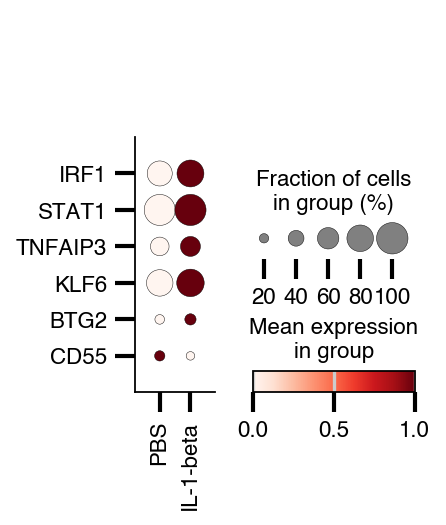

In [42]:
IL1B.obs["cytokine"] = IL1B.obs["cytokine"].astype("category")
IL1B.obs["cytokine"] = IL1B.obs["cytokine"].cat.reorder_categories(
    ["PBS", "IL-1-beta"],
    ordered=True
)

sc.pl.dotplot(IL1B,groupby='cytokine',var_names= ["IRF1", "STAT1","TNFAIP3","KLF6","BTG2","CD55"] , swap_axes=True,standard_scale='var',save='pbs.svg')

/tmp/ipykernel_4071960/2203273958.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/2203273958.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/2203273958.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/2203273958.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/2203273958.py:19: Fut

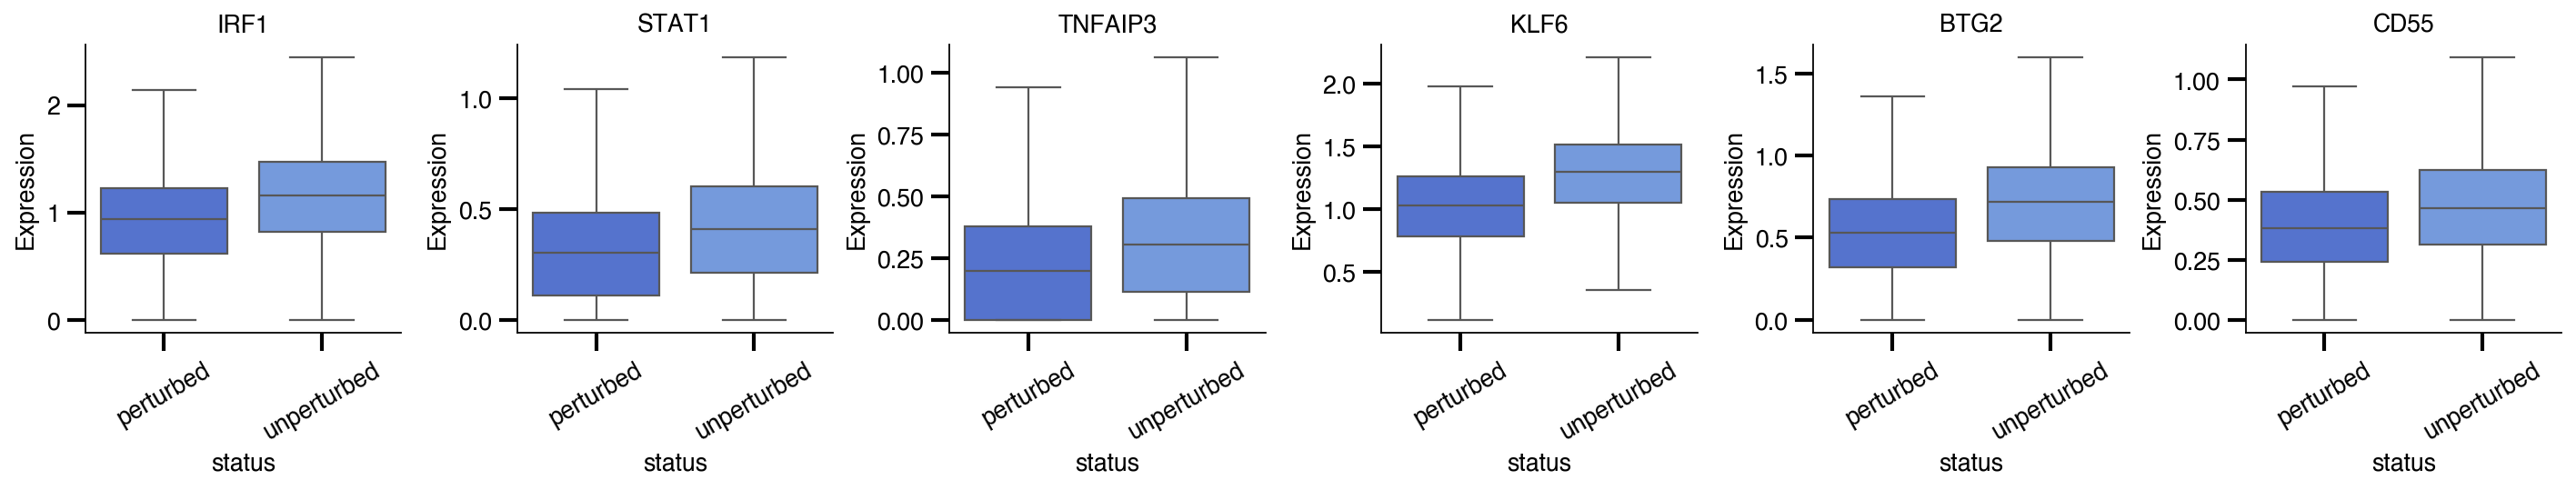

In [43]:
genes = ["IRF1", "STAT1","TNFAIP3","KLF6","BTG2","CD55"]

X = adata_6h[:, genes].X
if hasattr(X, "toarray"):
    X = X.toarray()

df = pd.DataFrame(X, columns=genes)
df["status"] = adata_6h.obs["status"].values

# Subplots (NOT sharing y-axis)
fig, axes = plt.subplots(1, 6, figsize=(18, 3.5) ,sharey=False)

palette = {
    "perturbed": "royalblue",
    "unperturbed": "cornflowerblue"
}

for ax, gene in zip(axes, genes):
    sns.boxplot(
        data=df,
        x="status",
        y=gene,
        ax=ax,
        showfliers=False,
        palette=palette
    )
    ax.set_title(gene)
    ax.set_xlabel("status")
    ax.set_ylabel("Expression")
    ax.grid(False) 
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.grid(False)
plt.savefig('./6h.svg',dpi=600)
plt.show()


/tmp/ipykernel_4071960/3332920458.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/3332920458.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/3332920458.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/3332920458.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/3332920458.py:19: Fut

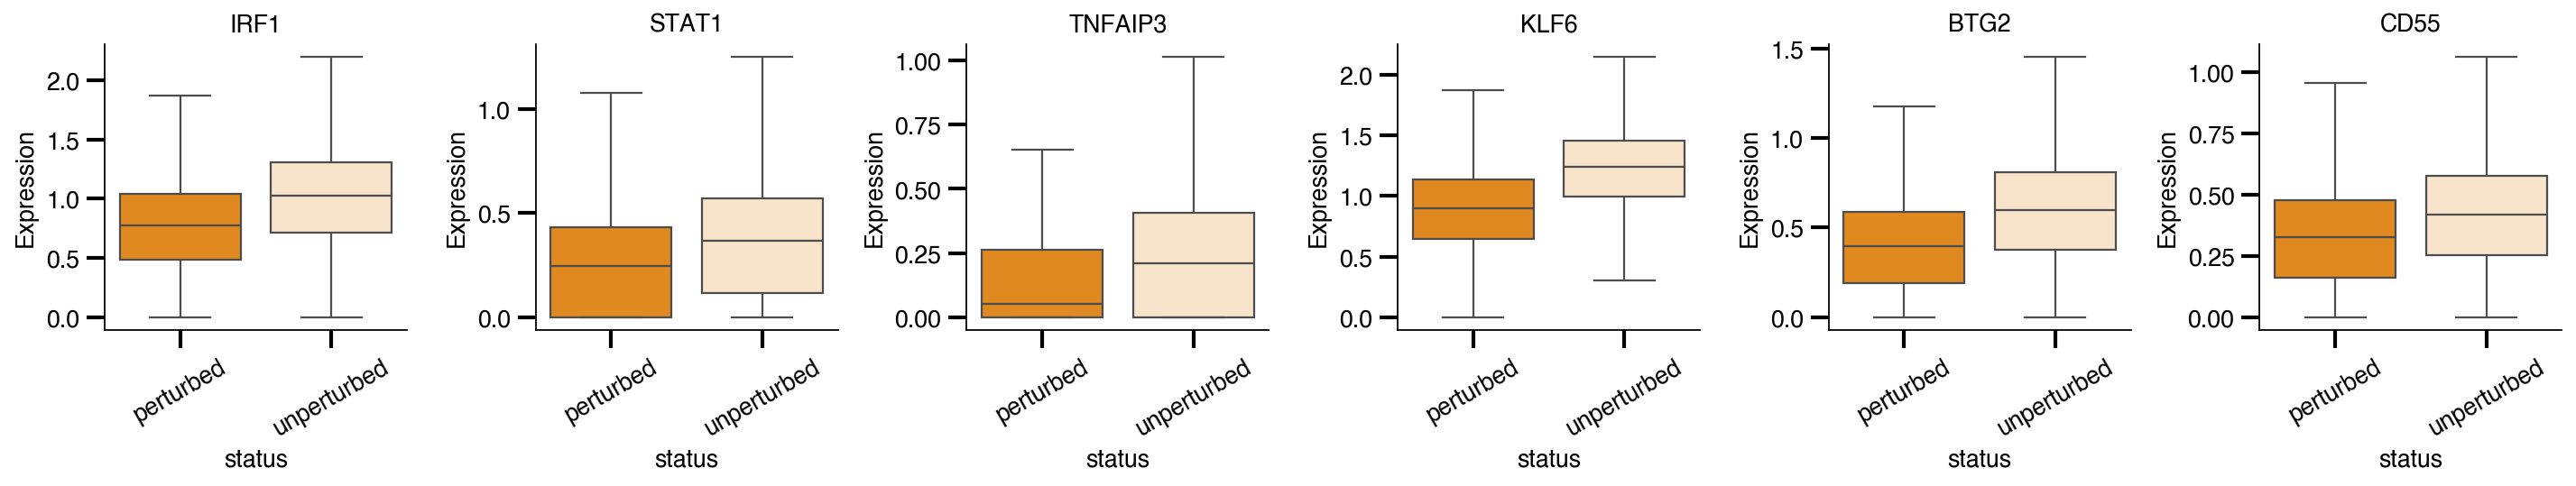

In [44]:
genes = ["IRF1", "STAT1","TNFAIP3","KLF6","BTG2","CD55"]

# Extract expression
X = adata_10h[:, genes].X
if hasattr(X, "toarray"):
    X = X.toarray()

df = pd.DataFrame(X, columns=genes)
df["status"] = adata_10h.obs["status"].values

# Subplots (NOT sharing y-axis)
fig, axes = plt.subplots(1, 6, figsize=(18, 3.5) ,sharey=False)

palette = {
    "perturbed": "darkorange",
    "unperturbed": "bisque"
}
for ax, gene in zip(axes, genes):
    sns.boxplot(
        data=df,
        x="status",
        y=gene,
        ax=ax,
        showfliers=False,
        palette=palette
    )
    ax.set_title(gene)
    ax.set_xlabel("status")
    ax.set_ylabel("Expression")
    ax.grid(False) 
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.grid(False)
plt.savefig('./10h.svg',dpi=600)
plt.show()

/tmp/ipykernel_4071960/2768913819.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/2768913819.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/2768913819.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/2768913819.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/2768913819.py:26: Fut

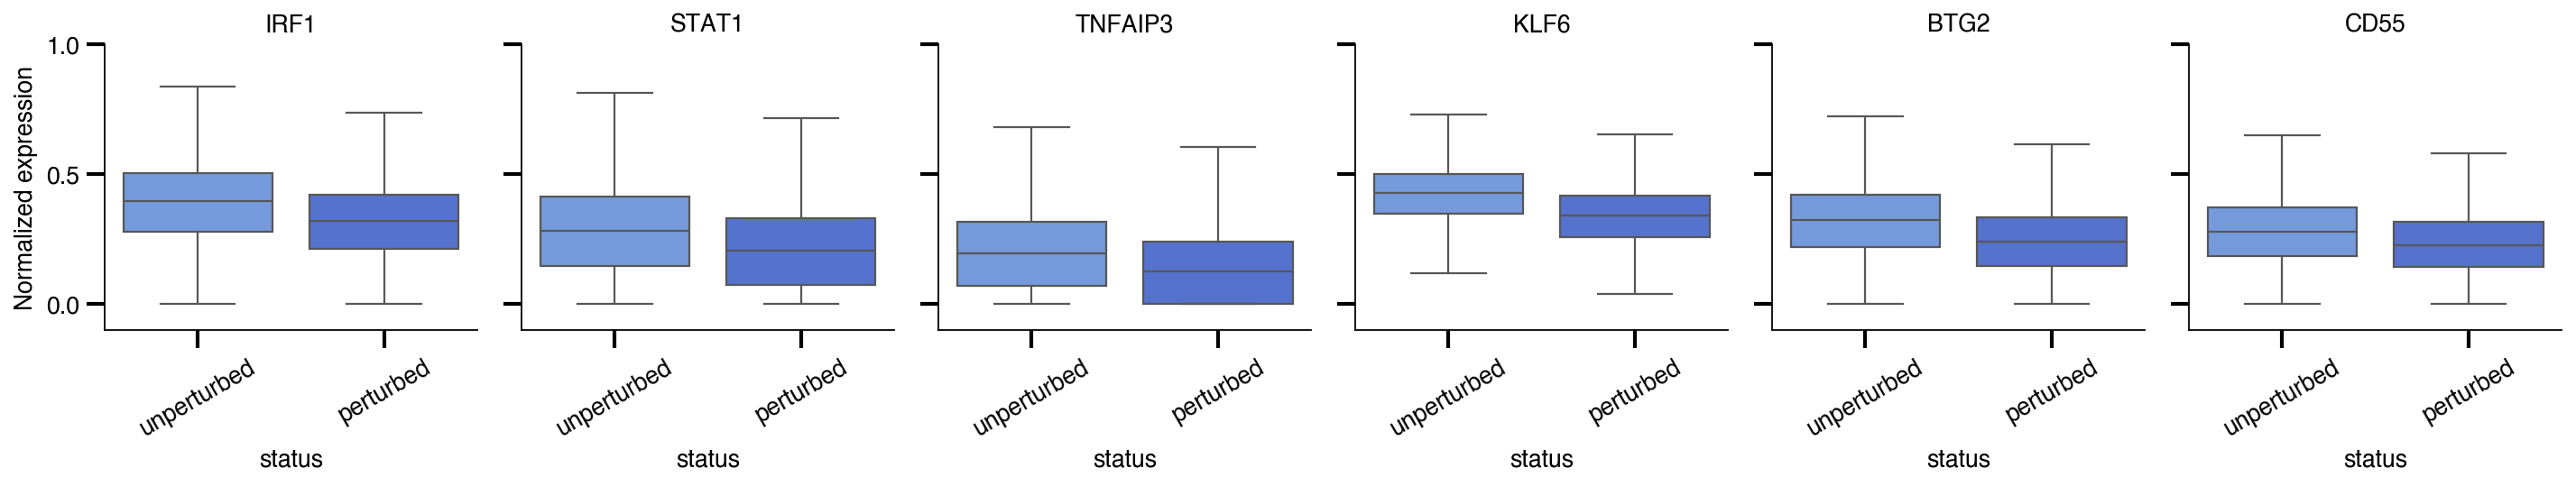

In [45]:
genes = ["IRF1", "STAT1","TNFAIP3","KLF6","BTG2","CD55"]

# Extract expression
X = adata_6h[:, genes].X
if hasattr(X, "toarray"):
    X = X.toarray()

# Create DataFrame
df = pd.DataFrame(X, columns=genes)

# Min-max normalization (0–1) per gene
df[genes] = (df[genes] - df[genes].min()) / (df[genes].max() - df[genes].min())

# Add status
df["status"] = adata_6h.obs["status"].values

# Subplots (NOT sharing y-axis)
fig, axes = plt.subplots(1, 6, figsize=(18, 3.5), sharey=True)

palette = {
    "perturbed": "royalblue",
    "unperturbed": "cornflowerblue"
}

for i, (ax, gene) in enumerate(zip(axes, genes)):
    sns.boxplot(
        data=df,
        x="status",
        y=gene,
        ax=ax,
        showfliers=False,
        palette=palette,
        order=["unperturbed", "perturbed"]
    )

    ax.set_title(gene)
    ax.set_xlabel("status")
    ax.set_ylim(-0.1, 1)
    ax.set_yticks([0, 0.5, 1])

    if i == 0:
        ax.set_ylabel("Normalized expression")
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.grid(False)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("./6h_norm.svg", dpi=600)
plt.show()



/tmp/ipykernel_4071960/475794434.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/475794434.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/475794434.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/475794434.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/475794434.py:26: FutureWa

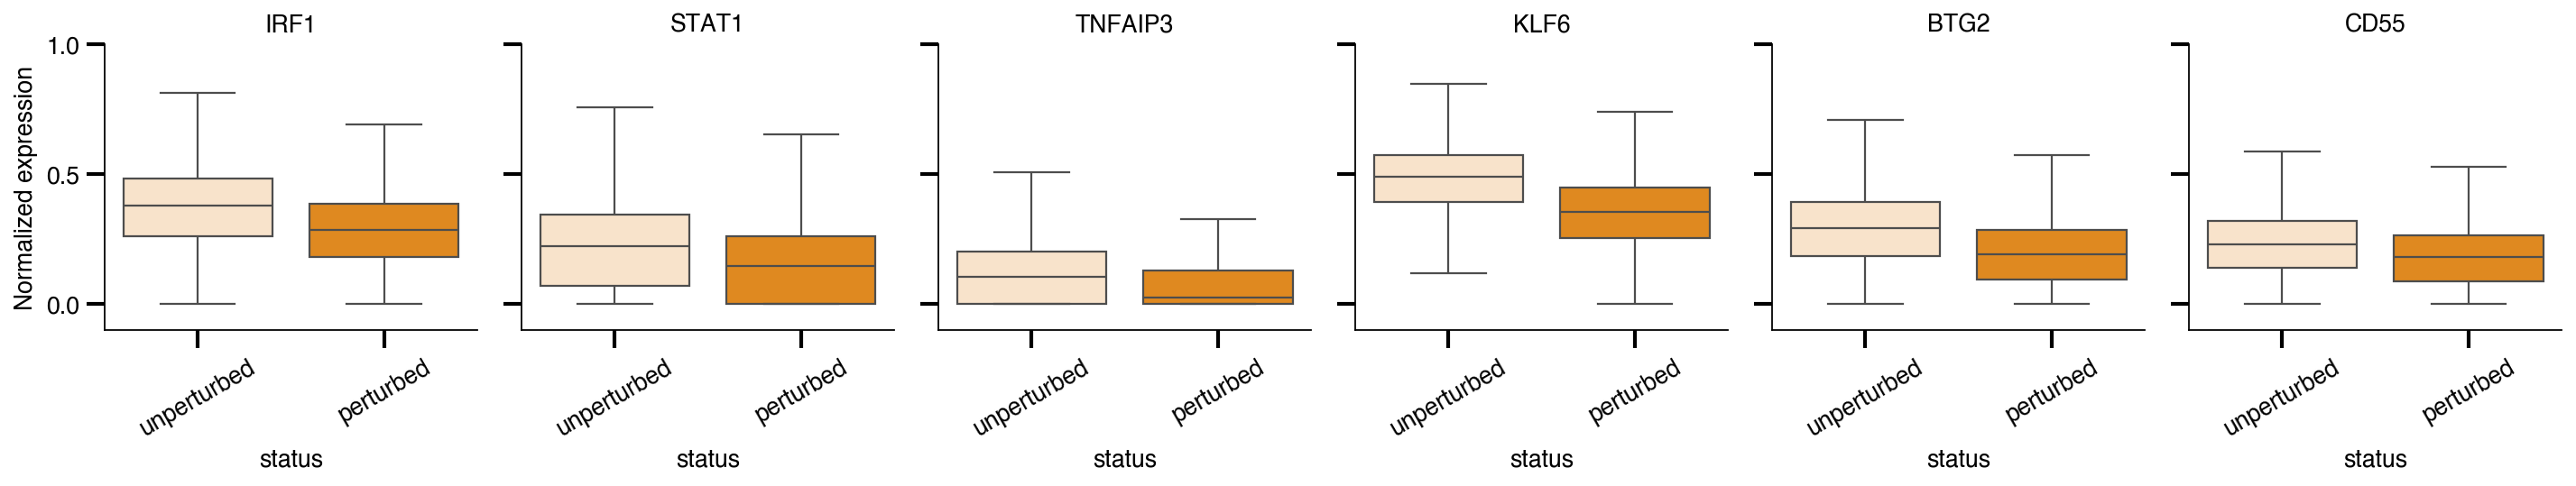

In [46]:
genes = ["IRF1", "STAT1","TNFAIP3","KLF6","BTG2","CD55"]

# Extract expression
X = adata_10h[:, genes].X
if hasattr(X, "toarray"):
    X = X.toarray()

# Create DataFrame
df = pd.DataFrame(X, columns=genes)

# Min-max normalization (0–1) per gene
df[genes] = (df[genes] - df[genes].min()) / (df[genes].max() - df[genes].min())

# Add status
df["status"] = adata_10h.obs["status"].values

# Subplots (NOT sharing y-axis)
fig, axes = plt.subplots(1, 6, figsize=(18, 3.5), sharey=True)

palette = {
    "perturbed": "darkorange",
    "unperturbed": "bisque"
}

for i, (ax, gene) in enumerate(zip(axes, genes)):
    sns.boxplot(
        data=df,
        x="status",
        y=gene,
        ax=ax,
        showfliers=False,
        palette=palette,
        order=["unperturbed", "perturbed"]
    )

    ax.set_title(gene)
    ax.set_xlabel("status")
    ax.set_ylim(-0.1, 1)
    ax.set_yticks([0, 0.5, 1])

    if i == 0:
        ax.set_ylabel("Normalized expression")
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.grid(False)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("./10h_norm.svg", dpi=600)
plt.show()


/tmp/ipykernel_4071960/2717671693.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/2717671693.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


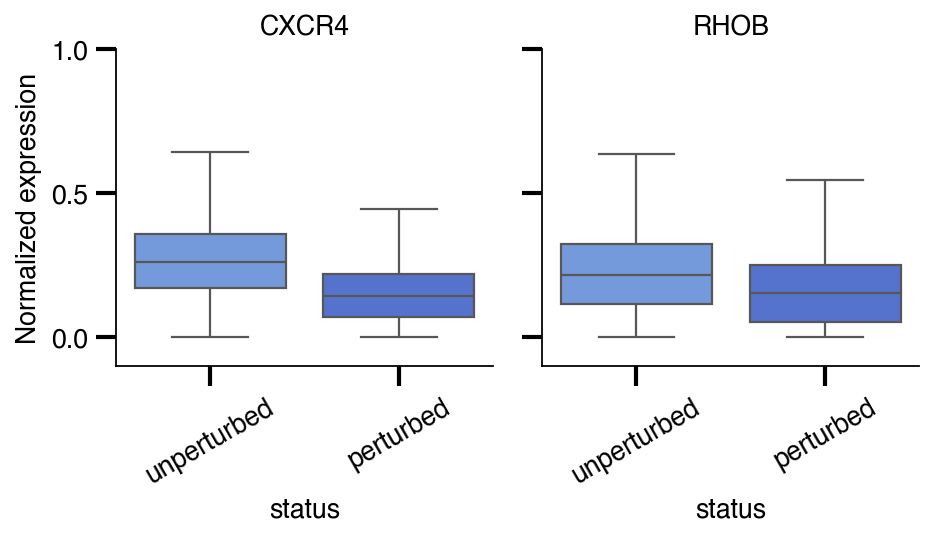

In [47]:
genes = ["CXCR4", "RHOB"]

# Extract expression
X = adata_6h[:, genes].X
if hasattr(X, "toarray"):
    X = X.toarray()

# Create DataFrame
df = pd.DataFrame(X, columns=genes)

# Min-max normalization (0–1) per gene
df[genes] = (df[genes] - df[genes].min()) / (df[genes].max() - df[genes].min())

# Add status
df["status"] = adata_6h.obs["status"].values

# Subplots (NOT sharing y-axis)
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)

palette = {
    "perturbed": "royalblue",
    "unperturbed": "cornflowerblue"
}

for i, (ax, gene) in enumerate(zip(axes, genes)):
    sns.boxplot(
        data=df,
        x="status",
        y=gene,
        ax=ax,
        showfliers=False,
        palette=palette,
        order=["unperturbed", "perturbed"]
    )

    ax.set_title(gene)
    ax.set_xlabel("status")
    ax.set_ylim(-0.1, 1)
    ax.set_yticks([0, 0.5, 1])

    if i == 0:
        ax.set_ylabel("Normalized expression")
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.grid(False)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("./6h_supp.svg", dpi=600)
plt.show()



/tmp/ipykernel_4071960/2085114850.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/2085114850.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


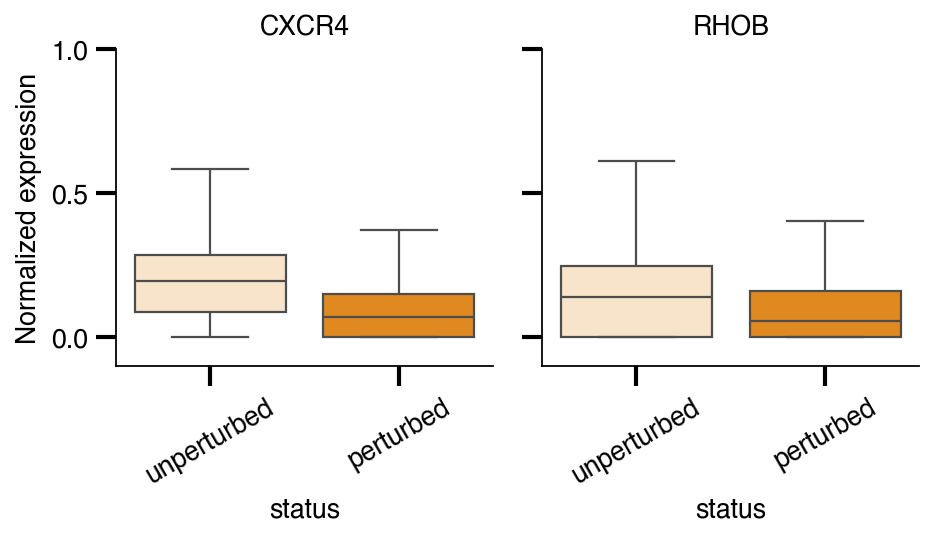

In [48]:
genes = ["CXCR4", "RHOB"]

# Extract expression
X = adata_10h[:, genes].X
if hasattr(X, "toarray"):
    X = X.toarray()

# Create DataFrame
df = pd.DataFrame(X, columns=genes)

# Min-max normalization (0–1) per gene
df[genes] = (df[genes] - df[genes].min()) / (df[genes].max() - df[genes].min())

# Add status
df["status"] = adata_10h.obs["status"].values

# Subplots (NOT sharing y-axis)
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)

palette = {
    "perturbed": "darkorange",
    "unperturbed": "bisque"
}

for i, (ax, gene) in enumerate(zip(axes, genes)):
    sns.boxplot(
        data=df,
        x="status",
        y=gene,
        ax=ax,
        showfliers=False,
        palette=palette,
        order=["unperturbed", "perturbed"]
    )

    ax.set_title(gene)
    ax.set_xlabel("status")
    ax.set_ylim(-0.1, 1)
    ax.set_yticks([0, 0.5, 1])

    if i == 0:
        ax.set_ylabel("Normalized expression")
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.grid(False)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("./10h_supp.svg", dpi=600)
plt.show()


/tmp/ipykernel_4071960/1006864452.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/1006864452.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


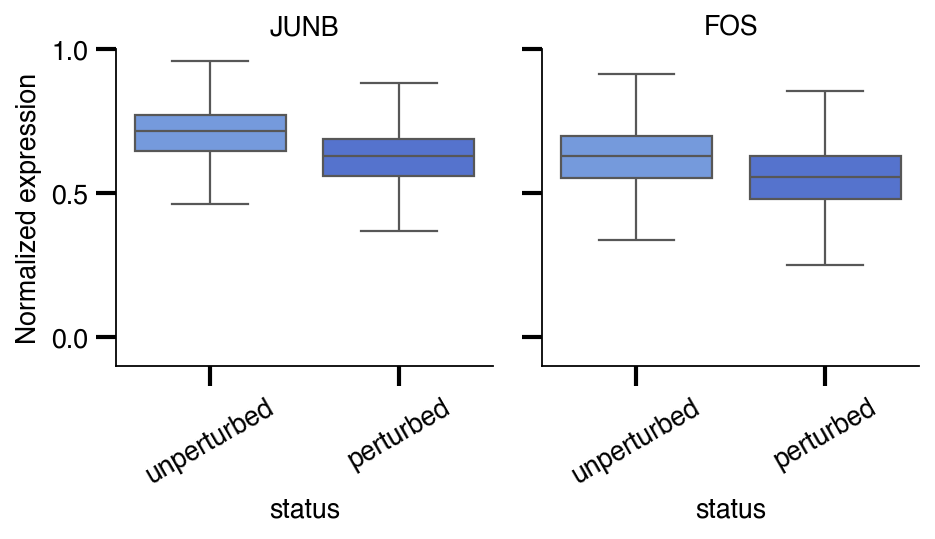

In [88]:
genes = ["JUNB",'FOS']

# Extract expression
X = adata_6h[:, genes].X
if hasattr(X, "toarray"):
    X = X.toarray()

# Create DataFrame
df = pd.DataFrame(X, columns=genes)

# Min-max normalization (0–1) per gene
df[genes] = (df[genes] - df[genes].min()) / (df[genes].max() - df[genes].min())

# Add status
df["status"] = adata_6h.obs["status"].values

# Subplots (NOT sharing y-axis)
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)

palette = {
    "perturbed": "royalblue",
    "unperturbed": "cornflowerblue"
}

for i, (ax, gene) in enumerate(zip(axes, genes)):
    sns.boxplot(
        data=df,
        x="status",
        y=gene,
        ax=ax,
        showfliers=False,
        palette=palette,
        order=["unperturbed", "perturbed"]
    )

    ax.set_title(gene)
    ax.set_xlabel("status")
    ax.set_ylim(-0.1, 1)
    ax.set_yticks([0, 0.5, 1])

    if i == 0:
        ax.set_ylabel("Normalized expression")
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.grid(False)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("./6h_supp2.svg", dpi=600)
plt.show()



/tmp/ipykernel_4071960/1415583732.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4071960/1415583732.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


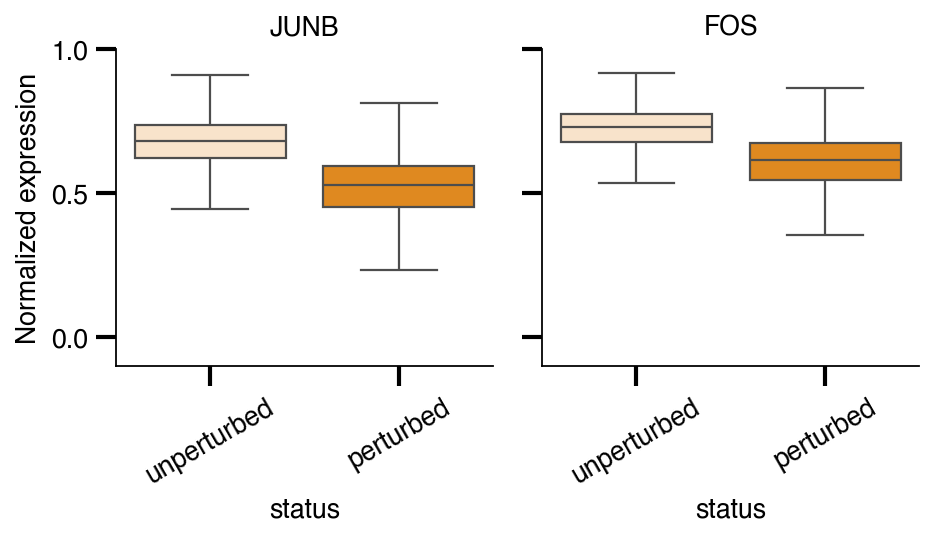

In [87]:
genes = ["JUNB",'FOS']

# Extract expression
X = adata_10h[:, genes].X
if hasattr(X, "toarray"):
    X = X.toarray()

# Create DataFrame
df = pd.DataFrame(X, columns=genes)

# Min-max normalization (0–1) per gene
df[genes] = (df[genes] - df[genes].min()) / (df[genes].max() - df[genes].min())

# Add status
df["status"] = adata_10h.obs["status"].values

# Subplots (NOT sharing y-axis)
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)

palette = {
    "perturbed": "darkorange",
    "unperturbed": "bisque"
}

for i, (ax, gene) in enumerate(zip(axes, genes)):
    sns.boxplot(
        data=df,
        x="status",
        y=gene,
        ax=ax,
        showfliers=False,
        palette=palette,
        order=["unperturbed", "perturbed"]
    )

    ax.set_title(gene)
    ax.set_xlabel("status")
    ax.set_ylim(-0.1, 1)
    ax.set_yticks([0, 0.5, 1])

    if i == 0:
        ax.set_ylabel("Normalized expression")
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.grid(False)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("./10h_supp2.svg", dpi=600)
plt.show()
